<a href="https://colab.research.google.com/github/Zekeriya-Ui/Zekeriya-Ui/blob/main/STA_210_and_211.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Probability and Statistics: A Python-Guided Overview

This notebook provides a comprehensive overview of fundamental and advanced concepts in Probability and Statistics, aligning with typical curricula for 'Probability and Statistics I' (STA 210) and 'Probability and Statistics II' (STA 211).

Each section will include theoretical explanations and practical Python examples using popular libraries like `numpy`, `scipy.stats`, `matplotlib`, and `seaborn`.

## STA 210: Probability and Statistics I

### 1. Introduction to Probability

Probability is the measure of the likelihood that an event will occur. It's a fundamental concept in statistics, helping us quantify uncertainty.

Key concepts include:
*   **Experiment:** A process that leads to one of several possible outcomes.
*   **Outcome:** A single result of an experiment.
*   **Sample Space (S):** The set of all possible outcomes of an experiment.
*   **Event (E):** A subset of the sample space (a collection of one or more outcomes).
*   **Probability of an Event P(E):** The ratio of the number of favorable outcomes to the total number of possible outcomes (for equally likely outcomes).

**Basic Probability Rules:**
1.  **P(E) is between 0 and 1:** $0 \le P(E) \le 1$.
2.  **Sum of probabilities:** The sum of probabilities of all possible outcomes in the sample space is 1.
3.  **Complement Rule:** $P(E') = 1 - P(E)$, where $E'$ is the complement of event E.
4.  **Addition Rule (for two events A and B):**
    *   **General:** $P(A \cup B) = P(A) + P(B) - P(A \cap B)$
    *   **Mutually Exclusive Events (A and B cannot occur together):** $P(A \cup B) = P(A) + P(B)$
5.  **Multiplication Rule (for two events A and B):**
    *   **General:** $P(A \cap B) = P(A|B)P(B) = P(B|A)P(A)$
    *   **Independent Events (Occurrence of one doesn't affect the other):** $P(A \cap B) = P(A)P(B)$
6.  **Conditional Probability:** $P(A|B) = \frac{P(A \cap B)}{P(B)}$, the probability of A given B.

In [ ]:
import numpy as np

# Example: Simulating a fair coin toss
num_tosses = 1000

# 0 for tails, 1 for heads
results = np.random.randint(0, 2, num_tosses)

# Calculate empirical probabilities
heads_count = np.sum(results == 1)
tails_count = np.sum(results == 0)

prob_heads = heads_count / num_tosses
prob_tails = tails_count / num_tosses

print(f"Number of tosses: {num_tosses}")
print(f"Heads count: {heads_count}, Probability of Heads: {prob_heads:.4f}")
print(f"Tails count: {tails_count}, Probability of Tails: {prob_tails:.4f}")

# Example: Simulating a fair six-sided die roll
num_rolls = 1000
die_results = np.random.randint(1, 7, num_rolls) # Numbers 1 to 6

# Probability of rolling a 3
prob_3 = np.sum(die_results == 3) / num_rolls
print(f"\nProbability of rolling a 3: {prob_3:.4f}")

# Probability of rolling an even number
even_numbers = [2, 4, 6]
prob_even = np.sum(np.isin(die_results, even_numbers)) / num_rolls
print(f"Probability of rolling an even number: {prob_even:.4f}")

### 2. Descriptive Statistics

Descriptive statistics are used to summarize and describe the main features of a dataset. They help us understand the data's characteristics without making inferences about a larger population.

**Measures of Central Tendency:** These describe the center point of the data.
*   **Mean:** The average of all values ($\bar{x} = \frac{\sum x_i}{n}$).
*   **Median:** The middle value when data is ordered. Less sensitive to outliers.
*   **Mode:** The most frequently occurring value.

**Measures of Dispersion (Variability):** These describe the spread or variability of the data.
*   **Range:** The difference between the maximum and minimum values.
*   **Variance ($\sigma^2$ or $s^2$):** The average of the squared differences from the mean. $\sigma^2 = \frac{\sum(x_i - \mu)^2}{N}$ (population) or $s^2 = \frac{\sum(x_i - \bar{x})^2}{n-1}$ (sample).
*   **Standard Deviation ($\sigma$ or $s$):** The square root of the variance. It's in the same units as the data, making it easier to interpret.
*   **Interquartile Range (IQR):** The range between the first quartile (Q1) and the third quartile (Q3). It represents the middle 50% of the data and is robust to outliers.

**Visualization:**
*   **Histograms:** Show the distribution of a numerical variable.
*   **Box Plots:** Display the distribution of numerical data and skewness by showing the quartiles (and medians) and averages.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate some sample data
data = np.array([12, 15, 18, 20, 22, 25, 25, 28, 30, 35, 40, 45, 50, 100]) # Added an outlier

# Create a Pandas Series for easier calculation and display
sample_series = pd.Series(data)

print("--- Measures of Central Tendency ---")
print(f"Mean: {sample_series.mean():.2f}")
print(f"Median: {sample_series.median():.2f}")
print(f"Mode: {sample_series.mode().tolist()}")

print("\n--- Measures of Dispersion ---")
print(f"Range: {sample_series.max() - sample_series.min():.2f}")
print(f"Variance (sample): {sample_series.var():.2f}") # Defaults to sample variance
print(f"Standard Deviation (sample): {sample_series.std():.2f}") # Defaults to sample std dev
print(f"Interquartile Range (IQR): {sample_series.quantile(0.75) - sample_series.quantile(0.25):.2f}")

# --- Visualization ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(sample_series, kde=True, bins=5) # kde for kernel density estimate
plt.title('Histogram of Sample Data')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=sample_series)
plt.title('Box Plot of Sample Data')
plt.ylabel('Value')

plt.tight_layout()
plt.show()

### 3. Random Variables and Probability Distributions

A **random variable** is a numerical description of the outcome of a statistical experiment. Random variables can be discrete or continuous.

*   **Discrete Random Variable:** A variable whose values can be counted (e.g., number of heads in coin tosses, number of defective items).
    *   **Probability Mass Function (PMF):** For a discrete random variable $X$, the PMF, denoted $P(x)$, gives the probability that $X$ takes on a specific value $x$, i.e., $P(X=x)$.
    *   **Cumulative Distribution Function (CDF):** For a discrete random variable $X$, the CDF, denoted $F(x)$, gives the probability that $X$ takes on a value less than or equal to $x$, i.e., $F(x) = P(X \le x) = \sum_{t \le x} P(t)$.

*   **Continuous Random Variable:** A variable that can take on any value within a given range (e.g., height, weight, time).
    *   **Probability Density Function (PDF):** For a continuous random variable $X$, the PDF, denoted $f(x)$, is a function such that the probability that $X$ falls within an interval $(a, b)$ is given by the integral of the PDF over that interval: $P(a < X < b) = \int_a^b f(x) dx$.
    *   **Cumulative Distribution Function (CDF):** For a continuous random variable $X$, the CDF, denoted $F(x)$, gives the probability that $X$ takes on a value less than or equal to $x$, i.e., $F(x) = P(X \le x) = \int_{-\infty}^x f(t) dt$.

**Common Discrete Distributions:**
*   **Bernoulli Distribution:** Models a single trial with two outcomes (success/failure).
*   **Binomial Distribution:** Models the number of successes in a fixed number of independent Bernoulli trials.
*   **Poisson Distribution:** Models the number of events occurring in a fixed interval of time or space.

**Common Continuous Distributions:**
*   **Uniform Distribution:** All values within a given range are equally likely.
*   **Normal (Gaussian) Distribution:** Bell-shaped curve, very common in nature and statistics due to the Central Limit Theorem.
*   **Exponential Distribution:** Models the time until an event occurs in a Poisson process.

--- Binomial Distribution (n=10, p=0.5) ---
PMF (P(X=x)): [0.00097656 0.00976563 0.04394531 0.1171875  0.20507812 0.24609375
 0.20507812 0.1171875  0.04394531 0.00976563 0.00097656]
CDF (P(X<=x)): [9.76562500e-04 1.07421875e-02 5.46875000e-02 1.71875000e-01
 3.76953125e-01 6.23046875e-01 8.28125000e-01 9.45312500e-01
 9.89257812e-01 9.99023438e-01 1.00000000e+00]


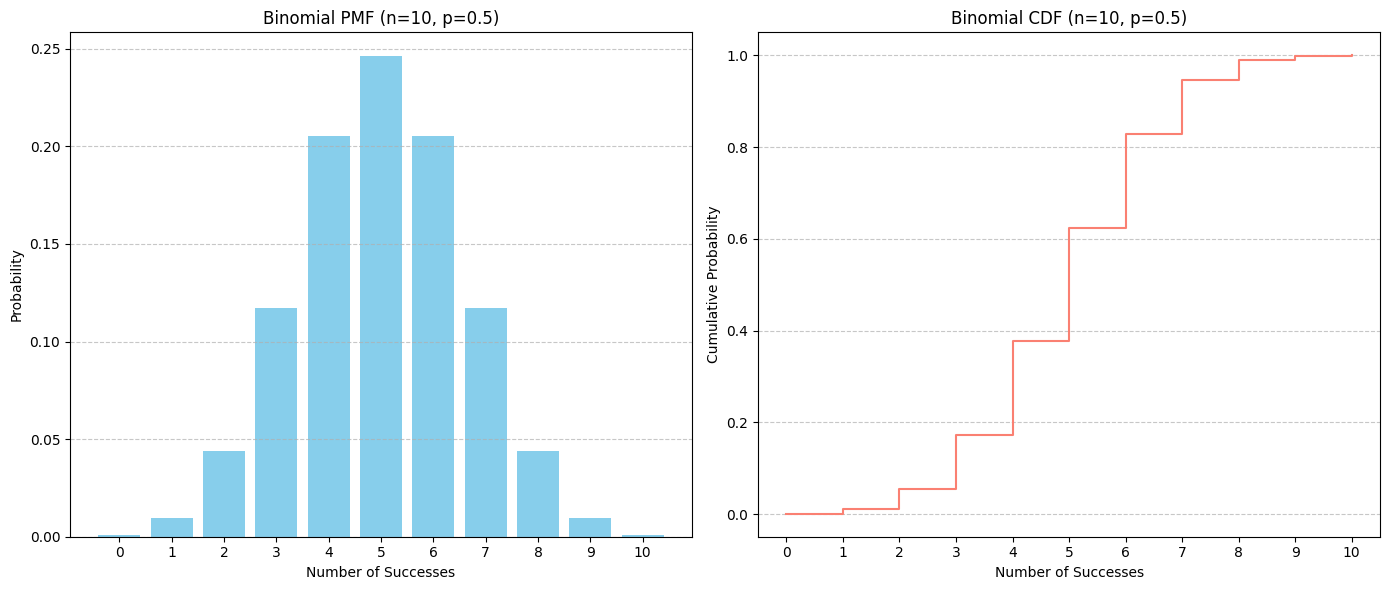


--- Poisson Distribution (lambda=3) ---
PMF (P(X=x)): [0.04978707 0.14936121 0.22404181 0.22404181 0.16803136 0.10081881
 0.05040941 0.02160403 0.00810151 0.0027005 ]
CDF (P(X<=x)): [0.04978707 0.19914827 0.42319008 0.64723189 0.81526324 0.91608206
 0.96649146 0.9880955  0.99619701 0.99889751]


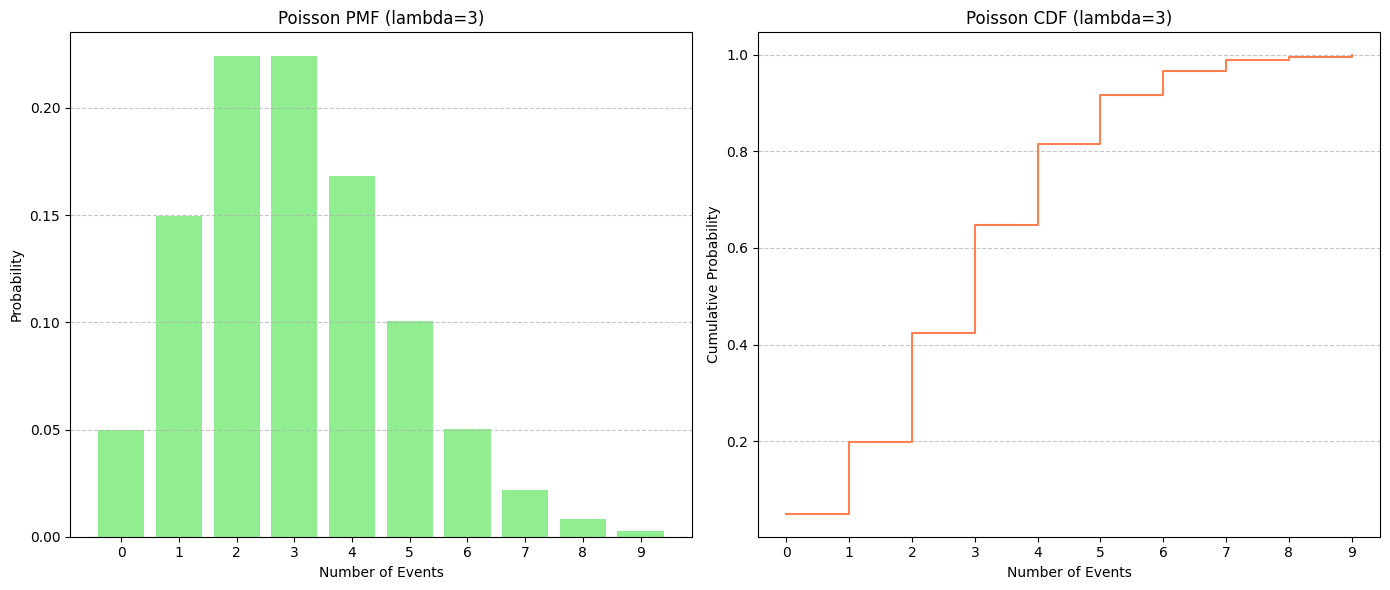


--- Normal Distribution (mu=0, sigma=1) ---
P(X < 0.5): 0.6915


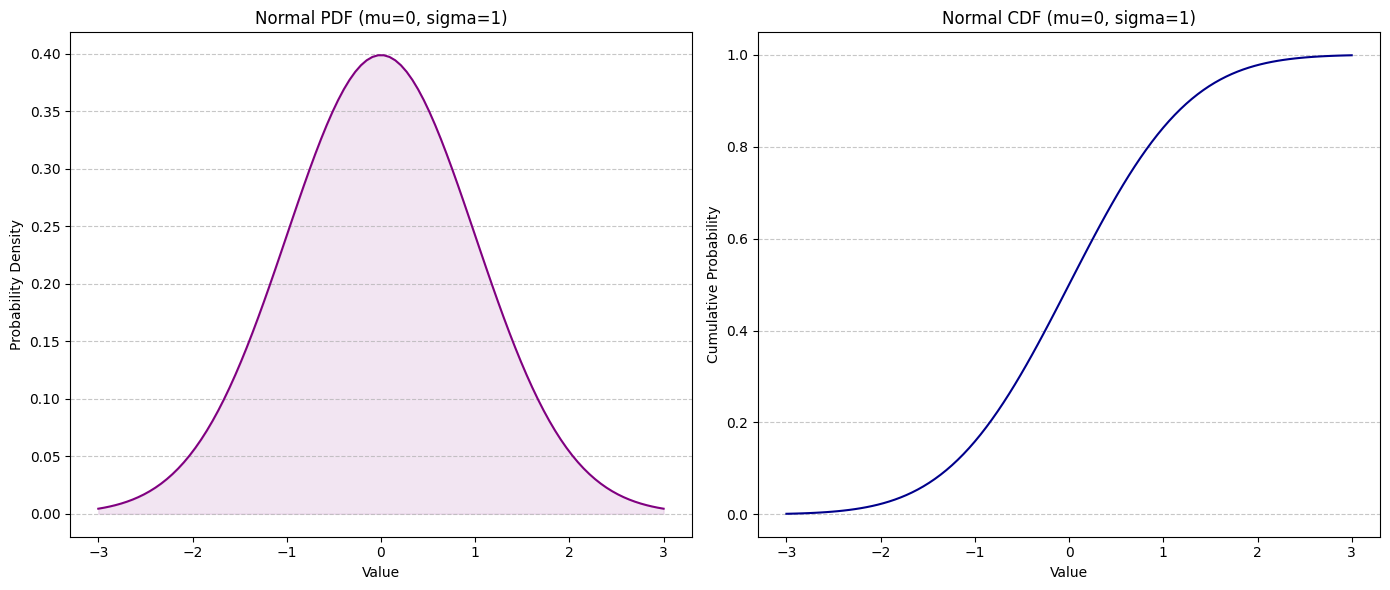

In [1]:
import numpy as np
from scipy.stats import binom, poisson, norm
import matplotlib.pyplot as plt
import seaborn as sns

# --- Discrete Distributions Examples ---

# Binomial Distribution: Number of heads in 10 coin tosses (p=0.5)
n = 10 # number of trials
p = 0.5 # probability of success
x = np.arange(0, n + 1) # possible number of successes

binomial_pmf = binom.pmf(x, n, p)
binomial_cdf = binom.cdf(x, n, p)

print("--- Binomial Distribution (n=10, p=0.5) ---")
print(f"PMF (P(X=x)): {binomial_pmf}")
print(f"CDF (P(X<=x)): {binomial_cdf}")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.bar(x, binomial_pmf, color='skyblue')
plt.title('Binomial PMF (n=10, p=0.5)')
plt.xlabel('Number of Successes')
plt.ylabel('Probability')
plt.xticks(x)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.step(x, binomial_cdf, where='post', color='salmon')
plt.title('Binomial CDF (n=10, p=0.5)')
plt.xlabel('Number of Successes')
plt.ylabel('Cumulative Probability')
plt.xticks(x)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Poisson Distribution: Number of events (lambda=3) in an interval
lambda_ = 3 # average rate of events
x_poisson = np.arange(0, 10) # possible number of events

poisson_pmf = poisson.pmf(x_poisson, lambda_)
poisson_cdf = poisson.cdf(x_poisson, lambda_)

print("\n--- Poisson Distribution (lambda=3) ---")
print(f"PMF (P(X=x)): {poisson_pmf}")
print(f"CDF (P(X<=x)): {poisson_cdf}")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.bar(x_poisson, poisson_pmf, color='lightgreen')
plt.title('Poisson PMF (lambda=3)')
plt.xlabel('Number of Events')
plt.ylabel('Probability')
plt.xticks(x_poisson)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.step(x_poisson, poisson_cdf, where='post', color='coral')
plt.title('Poisson CDF (lambda=3)')
plt.xlabel('Number of Events')
plt.ylabel('Cumulative Probability')
plt.xticks(x_poisson)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# --- Continuous Distribution Example ---

# Normal Distribution: Mean=0, StdDev=1 (Standard Normal)
mu = 0 # mean
sigma = 1 # standard deviation
x_norm = np.linspace(mu - 3*sigma, mu + 3*sigma, 100) # x-values for plotting

normal_pdf = norm.pdf(x_norm, mu, sigma)
normal_cdf = norm.cdf(x_norm, mu, sigma)

print("\n--- Normal Distribution (mu=0, sigma=1) ---")
# For continuous, we typically look at PDF values for plotting shape, not individual probabilities
# P(X < 0.5) for example:
prob_less_than_0_5 = norm.cdf(0.5, mu, sigma)
print(f"P(X < 0.5): {prob_less_than_0_5:.4f}")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(x_norm, normal_pdf, color='purple')
plt.fill_between(x_norm, normal_pdf, color='purple', alpha=0.1)
plt.title('Normal PDF (mu=0, sigma=1)')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(x_norm, normal_cdf, color='darkblue')
plt.title('Normal CDF (mu=0, sigma=1)')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 4. Sampling Distributions and the Central Limit Theorem

A **sampling distribution** is the probability distribution of a statistic (such as the mean, standard deviation, or proportion) obtained from a large number of samples drawn from a specific population.

**Key Concepts:**
*   **Population:** The entire group of individuals or instances about which we want to draw conclusions.
*   **Sample:** A subset of the population from which data is collected.
*   **Parameter:** A numerical characteristic of a population (e.g., population mean $\mu$, population standard deviation $\sigma$).
*   **Statistic:** A numerical characteristic of a sample (e.g., sample mean $\bar{x}$, sample standard deviation $s$).

**Central Limit Theorem (CLT):**
One of the most important theorems in statistics, the CLT states that if you take sufficiently large random samples from a population with mean $\mu$ and finite standard deviation $\sigma$, the distribution of the sample means will be approximately normally distributed, regardless of the shape of the original population distribution. The mean of this sampling distribution of sample means will be $\mu$, and its standard deviation (called the **standard error of the mean**) will be $\frac{\sigma}{\sqrt{n}}$, where $n$ is the sample size.

*   **Rule of Thumb:** The approximation is generally good if $n \ge 30$.
*   **Importance:** The CLT allows us to use normal distribution theory to make inferences about population means, even if the population itself is not normally distributed.


Sample Size (n=5):
  Mean of Sample Means: 4.96
  Standard Deviation of Sample Means (Empirical Standard Error): 2.20
  Theoretical Standard Error (from CLT): 2.24

Sample Size (n=30):
  Mean of Sample Means: 5.02
  Standard Deviation of Sample Means (Empirical Standard Error): 0.91
  Theoretical Standard Error (from CLT): 0.91

Sample Size (n=100):
  Mean of Sample Means: 4.99
  Standard Deviation of Sample Means (Empirical Standard Error): 0.49
  Theoretical Standard Error (from CLT): 0.50


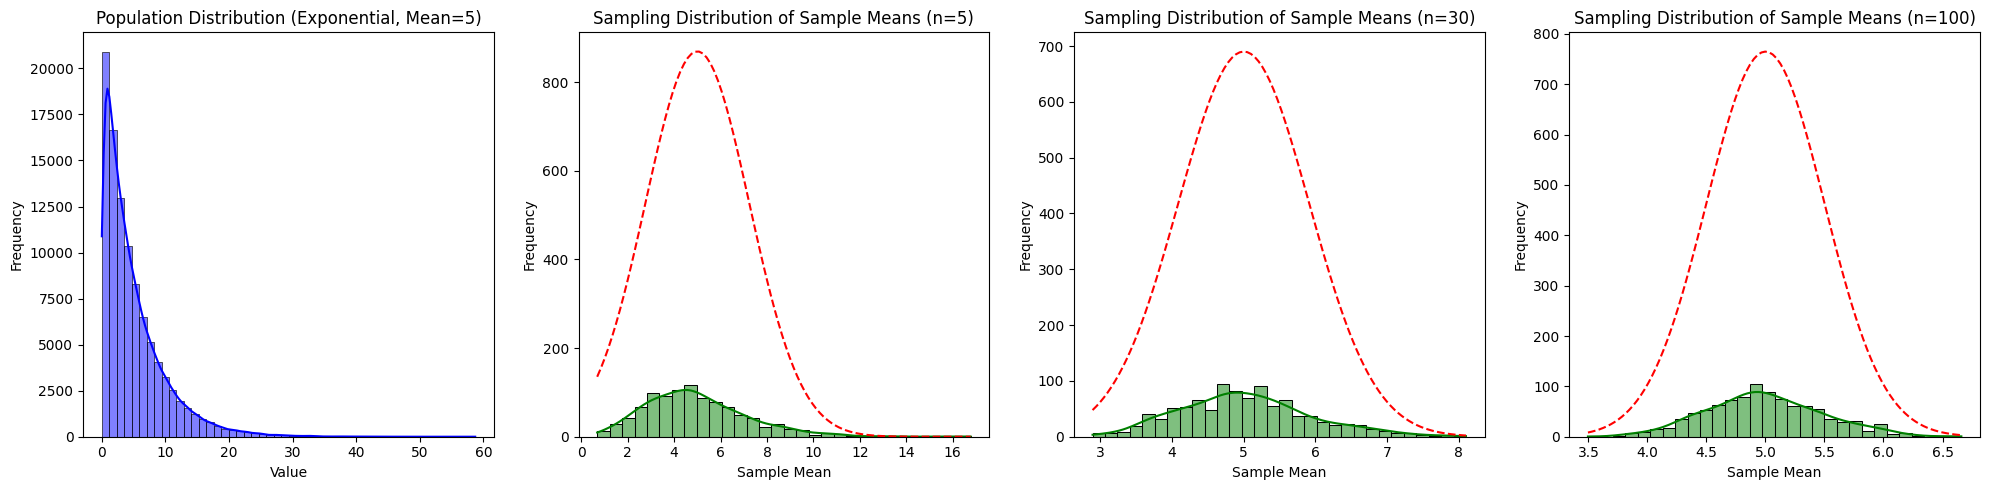

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import expon, norm

# --- Illustrating the Central Limit Theorem (CLT) ---

# 1. Define a non-normal population distribution (e.g., Exponential Distribution)
# Let's say the average waiting time is 5 minutes (lambda = 1/5 = 0.2)
population_mean = 5
population_std = 5 # For exponential distribution, mean = std = 1/lambda

# Generate a large population
population = expon.rvs(scale=population_mean, size=100000)

plt.figure(figsize=(20, 5)) # Adjusted figure size to accommodate 4 subplots

plt.subplot(1, 4, 1) # Changed to 1,4,1
sns.histplot(population, bins=50, kde=True, color='blue')
plt.title(f'Population Distribution (Exponential, Mean={population_mean})')
plt.xlabel('Value')
plt.ylabel('Frequency')

# 2. Take multiple samples and calculate their means
sample_sizes = [5, 30, 100] # Small, medium, large sample sizes
num_samples = 1000 # Number of samples to draw

sample_means = {n: [] for n in sample_sizes}

for n in sample_sizes:
    for _ in range(num_samples):
        sample = np.random.choice(population, size=n, replace=True)
        sample_means[n].append(np.mean(sample))

# 3. Plot the sampling distributions of the sample means
for i, n in enumerate(sample_sizes):
    plt.subplot(1, 4, i + 2) # Changed to 1,4,i+2
    sns.histplot(sample_means[n], bins=30, kde=True, color='green')
    plt.title(f'Sampling Distribution of Sample Means (n={n})')
    plt.xlabel('Sample Mean')
    plt.ylabel('Frequency')

    # Overlay the theoretical normal distribution from CLT
    clt_mean = population_mean
    clt_std_error = population_std / np.sqrt(n)
    x = np.linspace(min(sample_means[n]), max(sample_means[n]), 100)
    pdf = norm.pdf(x, clt_mean, clt_std_error)
    plt.plot(x, pdf * num_samples * (x[1]-x[0]) * 30, color='red', linestyle='--', label='CLT Normal Approx') # Scale PDF for histogram

    print(f"\nSample Size (n={n}):")
    print(f"  Mean of Sample Means: {np.mean(sample_means[n]):.2f}")
    print(f"  Standard Deviation of Sample Means (Empirical Standard Error): {np.std(sample_means[n]):.2f}")
    print(f"  Theoretical Standard Error (from CLT): {clt_std_error:.2f}")

plt.tight_layout()
plt.show()

### 5. Point and Interval Estimation

**Estimation** is the process of using sample data to estimate unknown population parameters.

**Point Estimation:**
*   A **point estimate** is a single value (a statistic) used to estimate a population parameter. For example, the sample mean $\bar{x}$ is a point estimate for the population mean $\mu$, and the sample proportion $\hat{p}$ is a point estimate for the population proportion $p$.

**Interval Estimation (Confidence Intervals):**
*   An **interval estimate** (or **confidence interval**) provides a range of values within which the population parameter is likely to lie, along with a level of confidence that the interval contains the true parameter.
*   A **confidence level** (e.g., 90%, 95%, 99%) indicates the long-run proportion of intervals that would contain the true parameter if the estimation process were repeated many times.

**Confidence Interval for a Population Mean ($\mu$):**
*   **When $\sigma$ is known:**
    $\bar{x} \pm z_{\alpha/2} \frac{\sigma}{\sqrt{n}}$
*   **When $\sigma$ is unknown (and $n \ge 30$ or population is normal):**
    $\bar{x} \pm t_{\alpha/2, df=n-1} \frac{s}{\sqrt{n}}$
    Here, $s$ is the sample standard deviation, and $t_{\alpha/2, df=n-1}$ is the critical value from the t-distribution with $n-1$ degrees of freedom.

**Confidence Interval for a Population Proportion ($p$):**
*   **Conditions:** $np \ge 10$ and $n(1-p) \ge 10$ (or use $\hat{p}$ instead of $p$ for checking conditions when $p$ is unknown).
*   $\hat{p} \pm z_{\alpha/2} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$
    Here, $\hat{p}$ is the sample proportion.

In [3]:
import numpy as np
from scipy.stats import norm, t

# --- Example 1: Confidence Interval for Population Mean (sigma known) ---
print("--- CI for Population Mean (sigma known) ---")
np.random.seed(42)
population_mean_true = 50
population_std_true = 10
sample_size_mu_known = 100

# Simulate a sample from this population
sample_data_mu_known = np.random.normal(loc=population_mean_true, scale=population_std_true, size=sample_size_mu_known)

sample_mean_mu_known = np.mean(sample_data_mu_known)
alpha = 0.05 # For 95% confidence
z_critical = norm.ppf(1 - alpha/2) # Two-tailed z-critical value

margin_of_error_mu_known = z_critical * (population_std_true / np.sqrt(sample_size_mu_known))

lower_bound_mu_known = sample_mean_mu_known - margin_of_error_mu_known
upper_bound_mu_known = sample_mean_mu_known + margin_of_error_mu_known

print(f"Sample Mean: {sample_mean_mu_known:.2f}")
print(f"Population Std Dev (known): {population_std_true}")
print(f"Sample Size: {sample_size_mu_known}")
print(f"Z-critical value for {100*(1-alpha)}% CI: {z_critical:.3f}")
print(f"Margin of Error: {margin_of_error_mu_known:.2f}")
print(f"{100*(1-alpha)}% Confidence Interval for Mean: ({lower_bound_mu_known:.2f}, {upper_bound_mu_known:.2f})")
print(f"True population mean ({population_mean_true}) is within the interval: {lower_bound_mu_known <= population_mean_true <= upper_bound_mu_known}")

# --- Example 2: Confidence Interval for Population Mean (sigma unknown, using t-distribution) ---
print("\n--- CI for Population Mean (sigma unknown) ---")
# Let's reuse the sample data from above, but now assume sigma is unknown
sample_data_mu_unknown = sample_data_mu_known # Using the same data for consistency
sample_size_mu_unknown = sample_size_mu_known

sample_mean_mu_unknown = np.mean(sample_data_mu_unknown)
sample_std_mu_unknown = np.std(sample_data_mu_unknown, ddof=1) # ddof=1 for sample standard deviation

alpha = 0.05 # For 95% confidence
degrees_of_freedom = sample_size_mu_unknown - 1
t_critical = t.ppf(1 - alpha/2, df=degrees_of_freedom) # Two-tailed t-critical value

margin_of_error_mu_unknown = t_critical * (sample_std_mu_unknown / np.sqrt(sample_size_mu_unknown))

lower_bound_mu_unknown = sample_mean_mu_unknown - margin_of_error_mu_unknown
upper_bound_mu_unknown = sample_mean_mu_unknown + margin_of_error_mu_unknown

print(f"Sample Mean: {sample_mean_mu_unknown:.2f}")
print(f"Sample Std Dev (estimated): {sample_std_mu_unknown:.2f}")
print(f"Sample Size: {sample_size_mu_unknown}")
print(f"T-critical value for {100*(1-alpha)}% CI (df={degrees_of_freedom}): {t_critical:.3f}")
print(f"Margin of Error: {margin_of_error_mu_unknown:.2f}")
print(f"{100*(1-alpha)}% Confidence Interval for Mean: ({lower_bound_mu_unknown:.2f}, {upper_bound_mu_unknown:.2f})")
print(f"True population mean ({population_mean_true}) is within the interval: {lower_bound_mu_unknown <= population_mean_true <= upper_bound_mu_unknown}")

# --- Example 3: Confidence Interval for Population Proportion ---
print("\n--- CI for Population Proportion ---")
num_successes = 65 # E.g., 65 out of 150 people prefer product A
total_trials = 150

sample_proportion = num_successes / total_trials

alpha = 0.05 # For 95% confidence
z_critical_prop = norm.ppf(1 - alpha/2)

# Check conditions for normality approximation (np >= 10, n(1-p) >= 10)
condition_success = total_trials * sample_proportion
condition_failure = total_trials * (1 - sample_proportion)

if condition_success >= 10 and condition_failure >= 10:
    std_error_prop = np.sqrt((sample_proportion * (1 - sample_proportion)) / total_trials)
    margin_of_error_prop = z_critical_prop * std_error_prop

    lower_bound_prop = sample_proportion - margin_of_error_prop
    upper_bound_prop = sample_proportion + margin_of_error_prop

    print(f"Sample Proportion (p-hat): {sample_proportion:.3f}")
    print(f"Total Trials: {total_trials}")
    print(f"Z-critical value for {100*(1-alpha)}% CI: {z_critical_prop:.3f}")
    print(f"Margin of Error: {margin_of_error_prop:.3f}")
    print(f"{100*(1-alpha)}% Confidence Interval for Proportion: ({lower_bound_prop:.3f}, {upper_bound_prop:.3f})")
else:
    print("Conditions for using the normal approximation for proportion CI are not met.")
    print(f"np-hat = {condition_success:.2f}, n(1-p-hat) = {condition_failure:.2f}")

--- CI for Population Mean (sigma known) ---
Sample Mean: 48.96
Population Std Dev (known): 10
Sample Size: 100
Z-critical value for 95.0% CI: 1.960
Margin of Error: 1.96
95.0% Confidence Interval for Mean: (47.00, 50.92)
True population mean (50) is within the interval: True

--- CI for Population Mean (sigma unknown) ---
Sample Mean: 48.96
Sample Std Dev (estimated): 9.08
Sample Size: 100
T-critical value for 95.0% CI (df=99): 1.984
Margin of Error: 1.80
95.0% Confidence Interval for Mean: (47.16, 50.76)
True population mean (50) is within the interval: True

--- CI for Population Proportion ---
Sample Proportion (p-hat): 0.433
Total Trials: 150
Z-critical value for 95.0% CI: 1.960
Margin of Error: 0.079
95.0% Confidence Interval for Proportion: (0.354, 0.513)


### 6. Hypothesis Testing

**Hypothesis testing** is a statistical method used to make decisions about a population based on sample data. It involves setting up two competing hypotheses and then using sample data to determine which hypothesis is more likely to be true.

**Key Concepts:**
*   **Null Hypothesis ($H_0$):** A statement of no effect or no difference. It's the hypothesis we aim to reject. (e.g., $H_0: \mu = 0$, $H_0: p_1 = p_2$).
*   **Alternative Hypothesis ($H_1$ or $H_A$):** A statement that contradicts the null hypothesis. It's what we conclude if we reject the null hypothesis. (e.g., $H_1: \mu \ne 0$, $H_1: p_1 \ne p_2$).
*   **Test Statistic:** A value calculated from sample data that is used to decide whether to reject the null hypothesis.
*   **P-value:** The probability of observing a test statistic as extreme as, or more extreme than, the one calculated from the sample data, assuming the null hypothesis is true. A small p-value (typically less than $\alpha$) indicates strong evidence against $H_0$.
*   **Significance Level ($\alpha$):** The maximum probability of rejecting a true null hypothesis (Type I error) that we are willing to accept. Common values are 0.05, 0.01, 0.10.
*   **Type I Error (False Positive):** Rejecting $H_0$ when $H_0$ is actually true. The probability of a Type I error is $\alpha$.
*   **Type II Error (False Negative):** Failing to reject $H_0$ when $H_0$ is actually false. The probability of a Type II error is denoted by $\beta$.

**Steps in Hypothesis Testing:**
1.  **State the Hypotheses:** Formulate $H_0$ and $H_1$.
2.  **Choose Significance Level:** Select an $\alpha$ (e.g., 0.05).
3.  **Calculate Test Statistic:** Compute the appropriate test statistic based on the sample data and chosen test.
4.  **Determine P-value (or Critical Value):** Find the p-value associated with the test statistic or determine critical value(s) for the chosen $\alpha$.
5.  **Make a Decision:**
    *   If P-value $\le \alpha$ (or test statistic falls in rejection region), **Reject $H_0$**.
    *   If P-value $> \alpha$ (or test statistic does not fall in rejection region), **Fail to Reject $H_0$**.
6.  **State Conclusion:** Interpret the decision in the context of the problem.

**Common Hypothesis Tests:**
*   **Z-test:** For population mean when population standard deviation is known (or for large samples).
*   **T-test:** For population mean when population standard deviation is unknown (and sample size is small or population is normal).
*   **Proportion Z-test:** For population proportion.
*   **Chi-Square Test:** For goodness-of-fit, independence of two categorical variables, or homogeneity.

In [5]:
import numpy as np
from scipy import stats

# --- Example 1: One-Sample Z-test for Mean (population std known) ---
print("--- One-Sample Z-test for Mean ---")
# A company claims its light bulbs last 1000 hours on average with a standard deviation of 50 hours.
# A sample of 30 bulbs has an average life of 980 hours.
# Test if the average life is significantly different from 1000 hours at alpha = 0.05.

mu_0 = 1000 # Hypothesized population mean
sigma = 50 # Population standard deviation (known)
n = 30 # Sample size
x_bar = 980 # Sample mean
alpha = 0.05

# Calculate the Z-statistic
z_statistic = (x_bar - mu_0) / (sigma / np.sqrt(n))

# Calculate the two-tailed p-value
p_value = 2 * stats.norm.cdf(z_statistic) if z_statistic < 0 else 2 * (1 - stats.norm.cdf(z_statistic))

print(f"Sample Mean (x_bar): {x_bar}")
print(f"Hypothesized Mean (mu_0): {mu_0}")
print(f"Population Std Dev (sigma): {sigma}")
print(f"Sample Size (n): {n}")
print(f"Z-statistic: {z_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print(f"Since P-value ({p_value:.4f}) < alpha ({alpha}), we reject the null hypothesis.")
    print("Conclusion: The average life of light bulbs is significantly different from 1000 hours.")
else:
    print(f"Since P-value ({p_value:.4f}) >= alpha ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is not enough evidence to claim the average life of light bulbs is different from 1000 hours.")

# --- Example 2: One-Sample T-test for Mean (population std unknown) ---
print("\n--- One-Sample T-test for Mean ---")
# A new fertilizer is tested on 15 plants. The average yield is 52 grams with a std dev of 8 grams.
# The standard yield is 50 grams. Test if the fertilizer increases yield at alpha = 0.01.

mu_0_t = 50 # Hypothesized population mean
sample_data_t = np.array([52, 55, 48, 53, 50, 57, 51, 54, 49, 56, 52, 50, 58, 53, 51]) # Sample data for illustration
n_t = len(sample_data_t)
x_bar_t = np.mean(sample_data_t)
s_t = np.std(sample_data_t, ddof=1) # Sample standard deviation
alpha_t = 0.01

# Perform one-sample t-test (right-tailed test: H1: mu > 50)
t_statistic, p_value_t = stats.ttest_1samp(sample_data_t, popmean=mu_0_t, alternative='greater')

print(f"Sample Mean (x_bar): {x_bar_t:.2f}")
print(f"Sample Std Dev (s): {s_t:.2f}")
print(f"Hypothesized Mean (mu_0): {mu_0_t}")
print(f"Sample Size (n): {n_t}")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value_t:.4f}")

if p_value_t < alpha_t:
    print(f"Since P-value ({p_value_t:.4f}) < alpha ({alpha_t}), we reject the null hypothesis.")
    print("Conclusion: The fertilizer significantly increases plant yield.")
else:
    print(f"Since P-value ({p_value_t:.4f}) >= alpha ({alpha_t}), we fail to reject the null hypothesis.")
    print("Conclusion: There is not enough evidence to claim the fertilizer increases plant yield.")

# --- Example 3: Two-Sample T-test (Independent Samples) ---
print("\n--- Two-Sample T-test (Independent Samples) ---")
# Compare exam scores of two different teaching methods.
# Method A: [85, 78, 90, 88, 92, 75, 80, 83, 91, 87]
# Method B: [70, 75, 80, 72, 68, 77, 82, 73, 79, 71]
# Test if there's a significant difference between the means at alpha = 0.05.

method_a_scores = np.array([85, 78, 90, 88, 92, 75, 80, 83, 91, 87])
method_b_scores = np.array([70, 75, 80, 72, 68, 77, 82, 73, 79, 71])
alpha_2samp = 0.05

# Perform independent two-sample t-test
# `equal_var=True` assumes equal population variances (pooled standard deviation)
# `equal_var=False` performs Welch's t-test (does not assume equal population variances)
# We'll use `equal_var=False` as it's generally safer without prior knowledge.
t_statistic_2samp, p_value_2samp = stats.ttest_ind(method_a_scores, method_b_scores, equal_var=False)

print(f"Mean Method A: {np.mean(method_a_scores):.2f}")
print(f"Mean Method B: {np.mean(method_b_scores):.2f}")
print(f"T-statistic: {t_statistic_2samp:.4f}")
print(f"P-value: {p_value_2samp:.4f}")

if p_value_2samp < alpha_2samp:
    print(f"Since P-value ({p_value_2samp:.4f}) < alpha ({alpha_2samp}), we reject the null hypothesis.")
    print("Conclusion: There is a significant difference in exam scores between the two teaching methods.")
else:
    print(f"Since P-value ({p_value_2samp:.4f}) >= alpha ({alpha_2samp}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no significant difference in exam scores between the two teaching methods.")


--- One-Sample Z-test for Mean ---
Sample Mean (x_bar): 980
Hypothesized Mean (mu_0): 1000
Population Std Dev (sigma): 50
Sample Size (n): 30
Z-statistic: -2.1909
P-value: 0.0285
Since P-value (0.0285) < alpha (0.05), we reject the null hypothesis.
Conclusion: The average life of light bulbs is significantly different from 1000 hours.

--- One-Sample T-test for Mean ---
Sample Mean (x_bar): 52.60
Sample Std Dev (s): 2.95
Hypothesized Mean (mu_0): 50
Sample Size (n): 15
T-statistic: 3.4168
P-value: 0.0021
Since P-value (0.0021) < alpha (0.01), we reject the null hypothesis.
Conclusion: The fertilizer significantly increases plant yield.

--- Two-Sample T-test (Independent Samples) ---
Mean Method A: 84.90
Mean Method B: 74.70
T-statistic: 4.3405
P-value: 0.0004
Since P-value (0.0004) < alpha (0.05), we reject the null hypothesis.
Conclusion: There is a significant difference in exam scores between the two teaching methods.


This concludes the typical topics covered in 'STA 210 Probability and Statistics I'. We have built a foundation from basic probability to descriptive statistics, understanding random variables and their distributions, the crucial Central Limit Theorem, estimation techniques, and finally, hypothesis testing.

## STA 211: Probability and Statistics II

STA 211 typically delves deeper into statistical inference, exploring more complex hypothesis tests, analysis of variance, correlation, regression, and sometimes non-parametric methods. It builds upon the foundational concepts established in STA 210.

### 1. Inference for Two Populations

Building on one-sample inference, STA 211 often focuses on comparing two different populations or two different treatments. This involves comparing their means, proportions, or variances.

**Comparing Two Population Means (Independent Samples):**
*   **Hypotheses:**
    *   $H_0: \mu_1 = \mu_2$ (No difference in means)
    *   $H_1: \mu_1 \ne \mu_2$ (Two-tailed), or $H_1: \mu_1 > \mu_2$ (Right-tailed), or $H_1: \mu_1 < \mu_2$ (Left-tailed)
*   **Test Statistic (t-test for two independent means):**
    *   **Equal Variances Assumed (Pooled t-test):** Requires checking if $\sigma_1^2 = \sigma_2^2$.
        $t = \frac{(\bar{x}_1 - \bar{x}_2) - (\mu_1 - \mu_2)}{s_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}$ where $s_p^2 = \frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}$. Degrees of freedom $df = n_1 + n_2 - 2$.
    *   **Unequal Variances Not Assumed (Welch's t-test):** Generally preferred if variance equality is uncertain.
        $t = \frac{(\bar{x}_1 - \bar{x}_2) - (\mu_1 - \mu_2)}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$. Degrees of freedom are calculated using the Welch-Satterthwaite equation (complex, but software handles it).

**Comparing Two Population Proportions:**
*   **Hypotheses:**
    *   $H_0: p_1 = p_2$ (No difference in proportions)
    *   $H_1: p_1 \ne p_2$ (Two-tailed), etc.
*   **Test Statistic (Pooled Z-test for proportions):**
    $Z = \frac{(\hat{p}_1 - \hat{p}_2) - (p_1 - p_2)}{\sqrt{\hat{p}(1-\hat{p})(\frac{1}{n_1} + \frac{1}{n_2})}}$ where $\hat{p} = \frac{x_1 + x_2}{n_1 + n_2}$ (pooled sample proportion).

In [6]:
import numpy as np
from scipy import stats

# --- Example 1: Two-Sample T-test for Means (Independent Samples, Unequal Variances) ---
print("--- Two-Sample T-test for Means (Independent Samples) ---")
# Scenario: Two different fertilizers (A and B) are tested on crop yield.
# Fertilizer A: Sample yields (kg/plot) from 12 plots.
# Fertilizer B: Sample yields (kg/plot) from 15 plots.
# Test if there is a significant difference in mean yields between the two fertilizers at alpha = 0.05.

fertilizer_a_yields = np.array([55, 58, 60, 57, 62, 59, 61, 56, 57, 60, 58, 63])
fertilizer_b_yields = np.array([50, 53, 52, 55, 51, 54, 50, 53, 52, 56, 51, 54, 53, 50, 52])
alpha = 0.05

# Perform independent two-sample t-test (Welch's t-test by setting equal_var=False)
t_statistic_means, p_value_means = stats.ttest_ind(fertilizer_a_yields, fertilizer_b_yields, equal_var=False)

print(f"Mean Yield Fertilizer A: {np.mean(fertilizer_a_yields):.2f}")
print(f"Mean Yield Fertilizer B: {np.mean(fertilizer_b_yields):.2f}")
print(f"T-statistic: {t_statistic_means:.4f}")
print(f"P-value: {p_value_means:.4f}")

if p_value_means < alpha:
    print(f"Since P-value ({p_value_means:.4f}) < alpha ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a significant difference in mean yields between the two fertilizers.")
else:
    print(f"Since P-value ({p_value_means:.4f}) >= alpha ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no significant difference in mean yields between the two fertilizers.")

# --- Example 2: Two-Sample Z-test for Proportions ---
print("\n--- Two-Sample Z-test for Proportions ---")
# Scenario: A new marketing campaign (Campaign A) is compared to an old one (Campaign B).
# Campaign A: 75 successes out of 200 customers.
# Campaign B: 60 successes out of 250 customers.
# Test if Campaign A has a higher success rate than Campaign B at alpha = 0.01.

x1 = 75 # Successes for Campaign A
n1 = 200 # Total for Campaign A
x2 = 60 # Successes for Campaign B
n2 = 250 # Total for Campaign B
alpha_prop = 0.01

p1_hat = x1 / n1
p2_hat = x2 / n2

# Pooled proportion for the null hypothesis
p_pooled = (x1 + x2) / (n1 + n2)

# Calculate the Z-statistic
# H0: p1 = p2 vs H1: p1 > p2 (right-tailed test)
z_statistic_prop = (p1_hat - p2_hat) / np.sqrt(p_pooled * (1 - p_pooled) * (1/n1 + 1/n2))

# Calculate the p-value for a right-tailed test
p_value_prop = 1 - stats.norm.cdf(z_statistic_prop)

print(f"Proportion Success Campaign A (p1_hat): {p1_hat:.3f}")
print(f"Proportion Success Campaign B (p2_hat): {p2_hat:.3f}")
print(f"Pooled Proportion (p_pooled): {p_pooled:.3f}")
print(f"Z-statistic: {z_statistic_prop:.4f}")
print(f"P-value: {p_value_prop:.4f}")

if p_value_prop < alpha_prop:
    print(f"Since P-value ({p_value_prop:.4f}) < alpha ({alpha_prop}), we reject the null hypothesis.")
    print("Conclusion: Campaign A has a significantly higher success rate than Campaign B.")
else:
    print(f"Since P-value ({p_value_prop:.4f}) >= alpha ({alpha_prop}), we fail to reject the null hypothesis.")
    print("Conclusion: There is not enough evidence to claim Campaign A has a higher success rate.")

--- Two-Sample T-test for Means (Independent Samples) ---
Mean Yield Fertilizer A: 58.83
Mean Yield Fertilizer B: 52.40
T-statistic: 7.5600
P-value: 0.0000
Since P-value (0.0000) < alpha (0.05), we reject the null hypothesis.
Conclusion: There is a significant difference in mean yields between the two fertilizers.

--- Two-Sample Z-test for Proportions ---
Proportion Success Campaign A (p1_hat): 0.375
Proportion Success Campaign B (p2_hat): 0.240
Pooled Proportion (p_pooled): 0.300
Z-statistic: 3.1053
P-value: 0.0010
Since P-value (0.0010) < alpha (0.01), we reject the null hypothesis.
Conclusion: Campaign A has a significantly higher success rate than Campaign B.


### 2. Analysis of Variance (ANOVA)

**Analysis of Variance (ANOVA)** is a statistical technique used to compare the means of three or more groups (populations) simultaneously. It tests whether there are any statistically significant differences between the means of the groups.

**Key Concepts:**
*   **One-Way ANOVA:** Used when you have one categorical independent variable (factor) and one quantitative dependent variable. It assesses whether the means of the dependent variable are equal across the different levels of the independent variable.
*   **Hypotheses for One-Way ANOVA:**
    *   $H_0: \mu_1 = \mu_2 = \dots = \mu_k$ (All group means are equal)
    *   $H_1:$ At least one group mean is different from the others.
*   **F-statistic:** The test statistic for ANOVA. It is the ratio of the variance between groups to the variance within groups.
    $F = \frac{\text{Variance Between Groups}}{\text{Variance Within Groups}} = \frac{\text{MSB}}{\text{MSW}}$
    *   **Mean Square Between (MSB):** Measures the variability among the group means.
    *   **Mean Square Within (MSW):** Measures the variability within each group.
*   **Assumptions of ANOVA:**
    1.  **Independence:** Observations within each group and between groups are independent.
    2.  **Normality:** The dependent variable is approximately normally distributed in each group.
    3.  **Homoscedasticity:** The variances of the dependent variable are equal across all groups.

In [7]:
import numpy as np
from scipy import stats
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# --- Example: One-Way ANOVA ---
print("--- One-Way ANOVA ---")
# Scenario: A nutritionist wants to compare the effectiveness of three different diets (Diet 1, Diet 2, Diet 3) on weight loss (in kg).
# They randomly assign participants to one of the three diets and record their weight loss after 2 months.

diet1_weight_loss = np.array([3.5, 4.2, 3.8, 4.5, 3.9, 4.1])
diet2_weight_loss = np.array([2.8, 3.1, 3.0, 2.9, 3.2, 2.7])
diet3_weight_loss = np.array([4.8, 5.1, 4.9, 5.5, 5.0, 5.2])
alpha = 0.05

print(f"Mean Weight Loss Diet 1: {np.mean(diet1_weight_loss):.2f}")
print(f"Mean Weight Loss Diet 2: {np.mean(diet2_weight_loss):.2f}")
print(f"Mean Weight Loss Diet 3: {np.mean(diet3_weight_loss):.2f}")

# Method 1: Using scipy.stats.f_oneway
f_statistic_scipy, p_value_scipy = stats.f_oneway(diet1_weight_loss, diet2_weight_loss, diet3_weight_loss)

print(f"\nUsing scipy.stats.f_oneway:")
print(f"F-statistic: {f_statistic_scipy:.4f}")
print(f"P-value: {p_value_scipy:.4f}")

if p_value_scipy < alpha:
    print(f"Since P-value ({p_value_scipy:.4f}) < alpha ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a significant difference in mean weight loss among the three diets.")
else:
    print(f"Since P-value ({p_value_scipy:.4f}) >= alpha ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no significant difference in mean weight loss among the three diets.")

# Method 2: Using statsmodels (provides more detailed ANOVA table)
# First, combine the data into a single DataFrame
data = pd.DataFrame({
    'Weight_Loss': np.concatenate([diet1_weight_loss, diet2_weight_loss, diet3_weight_loss]),
    'Diet': ['Diet 1']*len(diet1_weight_loss) +
            ['Diet 2']*len(diet2_weight_loss) +
            ['Diet 3']*len(diet3_weight_loss)
})

# Perform OLS (Ordinary Least Squares) regression to fit the ANOVA model
model = ols('Weight_Loss ~ C(Diet)', data=data).fit()

# Perform ANOVA and print the results table
anova_table = sm.stats.anova_lm(model, typ=2)

print(f"\nUsing statsmodels (ANOVA Table):\n{anova_table}")

# Extract p-value from the ANOVA table for the 'C(Diet)' factor
p_value_statsmodels = anova_table['PR(>F)'][0]

if p_value_statsmodels < alpha:
    print(f"Since P-value ({p_value_statsmodels:.4f}) < alpha ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a significant difference in mean weight loss among the three diets.")
else:
    print(f"Since P-value ({p_value_statsmodels:.4f}) >= alpha ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no significant difference in mean weight loss among the three diets.")

--- One-Way ANOVA ---
Mean Weight Loss Diet 1: 4.00
Mean Weight Loss Diet 2: 2.95
Mean Weight Loss Diet 3: 5.08

Using scipy.stats.f_oneway:
F-statistic: 94.5308
P-value: 0.0000
Since P-value (0.0000) < alpha (0.05), we reject the null hypothesis.
Conclusion: There is a significant difference in mean weight loss among the three diets.

Using statsmodels (ANOVA Table):
             sum_sq    df          F        PR(>F)
C(Diet)   13.654444   2.0  94.530769  3.143951e-09
Residual   1.083333  15.0        NaN           NaN
Since P-value (0.0000) < alpha (0.05), we reject the null hypothesis.
Conclusion: There is a significant difference in mean weight loss among the three diets.


/tmp/ipykernel_1316/3869256931.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value_statsmodels = anova_table['PR(>F)'][0]
